In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib


In [ ]:
df = pd.read_csv(
    "C:/Projects/Retail Sales Prediction & Business Performance Analytics/data/featured_data.csv",
    parse_dates=['Date']
)

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoMonths,SalesPerCustomer,CompetitionNearby,StoreAgeDays,Lag_1,Lag_7,Lag_30,Rolling7Mean,Rolling30Mean,Rolling7Std
0,1,2,2013-01-01,0,0,0,0,a,1,c,...,0.0,0.000000,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,3,2013-01-02,5530,668,1,0,0,1,c,...,0.0,8.278443,0,1,0.0,0.0,0.0,0.0,0.0,0.0
2,1,4,2013-01-03,4327,578,1,0,0,1,c,...,0.0,7.486159,0,2,5530.0,0.0,0.0,0.0,0.0,0.0
3,1,5,2013-01-04,4486,619,1,0,0,1,c,...,0.0,7.247173,0,3,4327.0,0.0,0.0,0.0,0.0,0.0
4,1,6,2013-01-05,4997,635,1,0,0,1,c,...,0.0,7.869291,0,4,4486.0,0.0,0.0,0.0,0.0,0.0


In [21]:
print(df.shape)

display(df.head())

df.info()

(1017209, 41)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoMonths,SalesPerCustomer,CompetitionNearby,StoreAgeDays,Lag_1,Lag_7,Lag_30,Rolling7Mean,Rolling30Mean,Rolling7Std
0,1,2,2013-01-01,0,0,0,0,a,1,c,...,0.0,0.000000,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,3,2013-01-02,5530,668,1,0,0,1,c,...,0.0,8.278443,0,1,0.0,0.0,0.0,0.0,0.0,0.0
2,1,4,2013-01-03,4327,578,1,0,0,1,c,...,0.0,7.486159,0,2,5530.0,0.0,0.0,0.0,0.0,0.0
3,1,5,2013-01-04,4486,619,1,0,0,1,c,...,0.0,7.247173,0,3,4327.0,0.0,0.0,0.0,0.0,0.0
4,1,6,2013-01-05,4997,635,1,0,0,1,c,...,0.0,7.869291,0,4,4486.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 41 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1017209 no

In [22]:
df.drop(
    columns=[
        'MonthName',
        'Weekday'
    ],
    inplace=True
)

Encode Categorical Variables

In [23]:
categorical_columns = [

    'StoreType',

    'Assortment',

    'StateHoliday',

    'PromoInterval'

]

label_encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = encoder

Sort Dataset

In [24]:
df = df.sort_values(

    ['Store','Date']

).reset_index(drop=True)

Time-Based Split

In [25]:
split_date = '2015-06-15'

train = df[
    df['Date'] < split_date
]

test = df[
    df['Date'] >= split_date
]

Features & Target

In [26]:
X_train = train.drop(
    columns=['Sales','Date']
)

y_train = train['Sales']

X_test = test.drop(
    columns=['Sales','Date']
)

y_test = test['Sales']

In [27]:
X_train = X_train.drop(columns=['SalesPerCustomer', 'Customers'])
X_test = X_test.drop(columns=['SalesPerCustomer', 'Customers'])

In [28]:
print("Training Set")

print(X_train.shape)

print()

print("Testing Set")

print(X_test.shape)

Training Set
(964804, 35)

Testing Set
(52405, 35)


Linear Regression

In [29]:
lr = LinearRegression()

lr.fit(

    X_train,

    y_train

)

lr_pred = lr.predict(X_test)

Random Forest

In [30]:
rf = RandomForestRegressor(

    n_estimators=300,

    max_depth=15,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

rf_pred = rf.predict(X_test)

XGBoost

In [31]:
xgb = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42

)

xgb.fit(

    X_train,

    y_train

)

xgb_pred = xgb.predict(X_test)

Evaluation Function

In [36]:
def evaluate(y_true, pred):

    mae = mean_absolute_error(y_true, pred)

    rmse = np.sqrt(mean_squared_error(y_true, pred))

    r2 = r2_score(y_true, pred)

    # Ignore rows where actual sales are zero
    mask = y_true != 0

    mape = np.mean(
        np.abs((y_true[mask] - pred[mask]) / y_true[mask])
    ) * 100

    return mae, rmse, r2, mape

Compare Models

In [37]:
models = {

    'Linear Regression':lr_pred,

    'Random Forest':rf_pred,

    'XGBoost':xgb_pred

}

results = []

for name,pred in models.items():

    mae,rmse,r2,mape = evaluate(

        y_test,

        pred

    )

    results.append([

        name,

        mae,

        rmse,

        r2,

        mape

    ])

results = pd.DataFrame(

    results,

    columns=[

        'Model',

        'MAE',

        'RMSE',

        'R2',

        'MAPE'

    ]

)

results.sort_values(

    by='RMSE'

)

,Model,MAE,RMSE,R2,MAPE
2,XGBoost,523.103455,791.300156,0.955063,8.729088
1,Random Forest,541.549098,835.304863,0.949927,9.097513
0,Linear Regression,1025.704576,1446.522222,0.849835,15.023450


Accuracy Metric

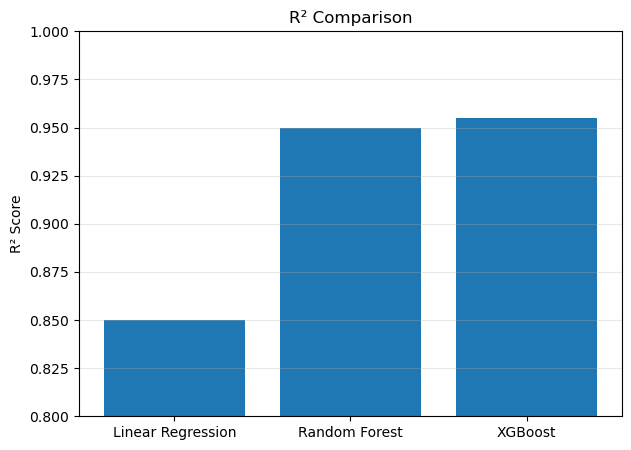

In [43]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["R2"])

plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.ylim(0.8, 1.0)

plt.grid(axis="y", alpha=0.3)

plt.show()

MAE

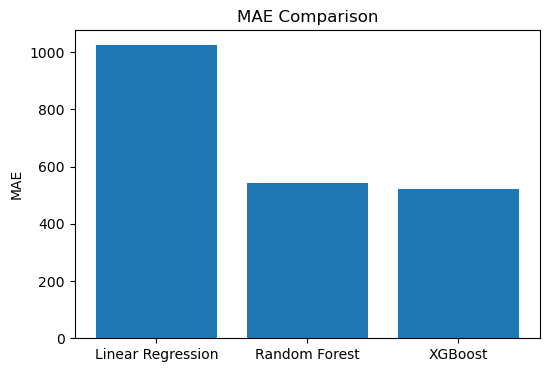

In [45]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

RMSE

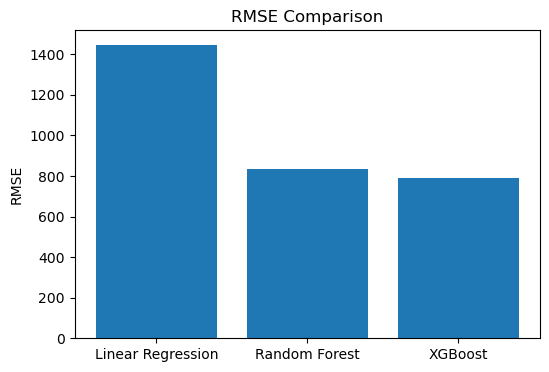

In [46]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

MAPE

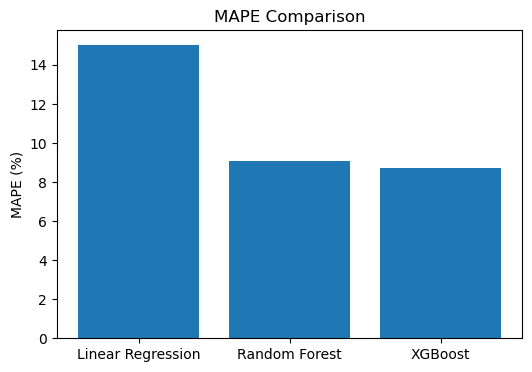

In [47]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAPE"])
plt.title("MAPE Comparison")
plt.ylabel("MAPE (%)")
plt.show()

Actual vs Predicted

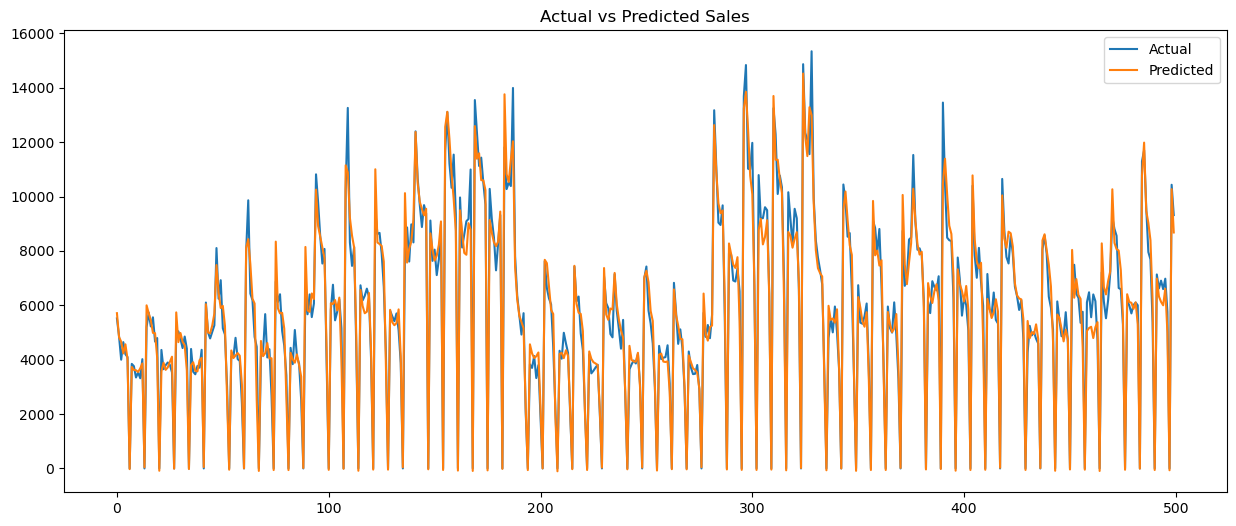

In [38]:
plt.figure(figsize=(15,6))

plt.plot(

    y_test.values[:500],

    label='Actual'

)

plt.plot(

    xgb_pred[:500],

    label='Predicted'

)

plt.title("Actual vs Predicted Sales")

plt.legend()

plt.show()

Feature Importance

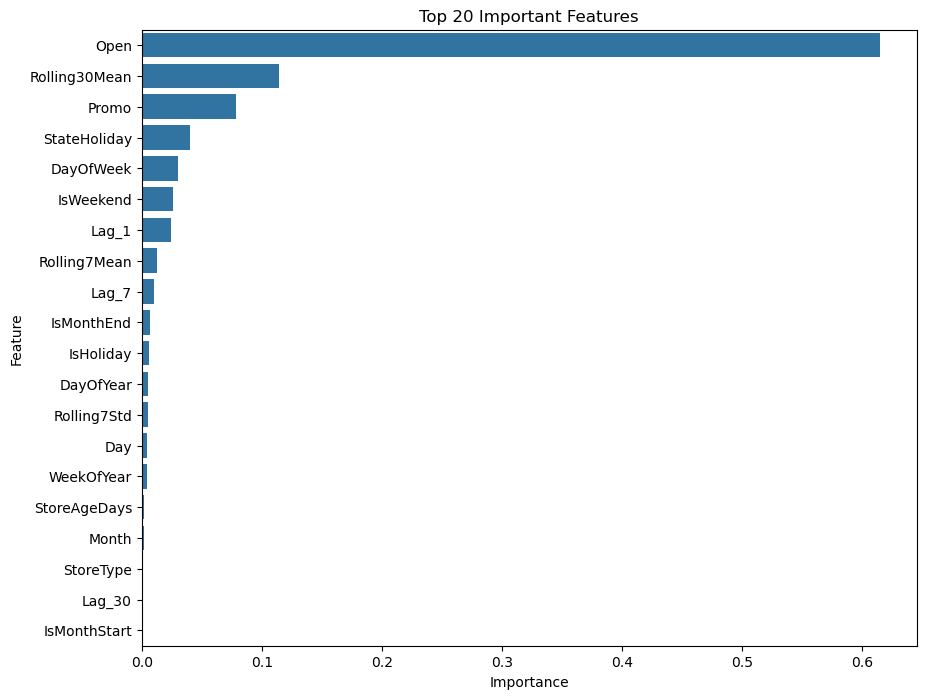

In [39]:
importance = pd.DataFrame({

    'Feature':X_train.columns,

    'Importance':xgb.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x='Importance',

    y='Feature'

)

plt.title("Top 20 Important Features")

plt.show()

Residual Distribution

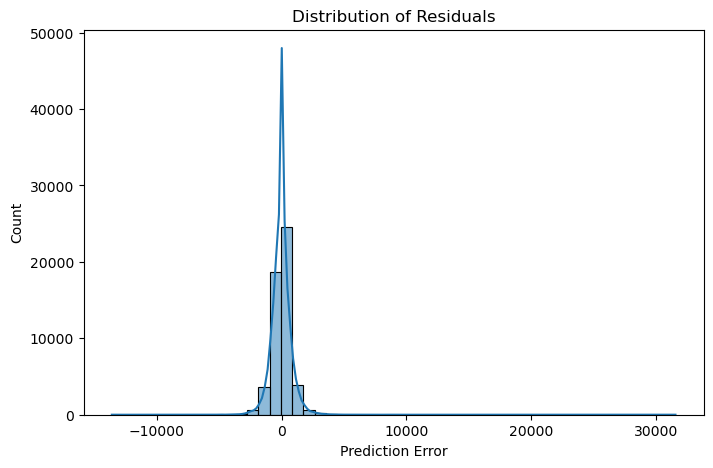

In [40]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Prediction Error")

plt.show()

Actual vs Predicted

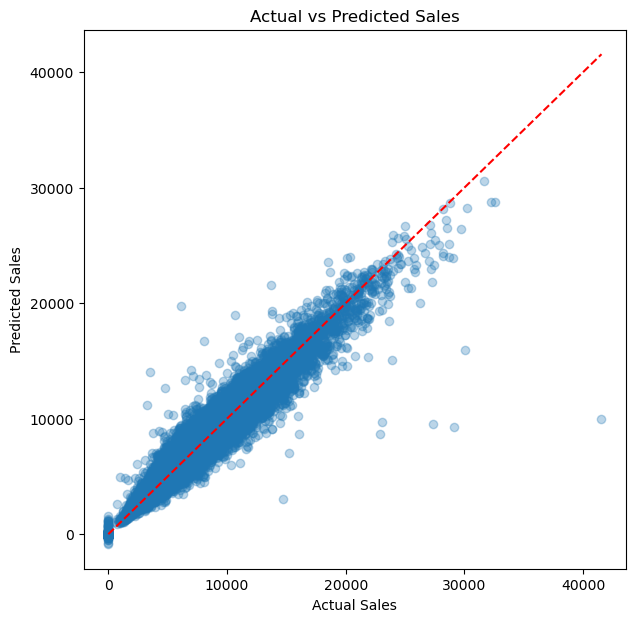

In [41]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()